# National Power Outlook Through 2030

This notebook evaluates whether planned U.S. power capacity additions are large enough to support potential AI and data center electricity demand growth through 2030.

The analysis uses a simple scenario framework rather than a precise forecast.

The goal is to connect national power system constraints to the regional competitiveness and behind-the-meter economics developed in earlier notebooks.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "outputs").exists():
    if (PROJECT_ROOT.parent / "outputs").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False,
})

## Baseline Inputs

This notebook uses national-level U.S. electricity system values from EIA state electricity profiles.

Current U.S. electricity system values:

- Current U.S. net summer capacity: 1,230,416 MW
- Current U.S. net generation: 4,308,634,297 MWh
- Current U.S. total retail electricity sales: 3,975,381,832 MWh

Planned capacity additions through 2030 are represented using a simplified national pipeline:

- Solar: 120,000 MW
- Battery storage: 65,000 MW
- Natural gas: 35,000 MW
- Total planned additions: 254,000 MW

Because not all planned projects are completed on time, the model includes realization-rate scenarios.

In [2]:
current_capacity_mw = 1_230_416
current_generation_mwh = 4_308_634_297
current_retail_sales_mwh = 3_975_381_832

planned_solar_mw = 120_000
planned_battery_mw = 65_000
planned_gas_mw = 35_000
planned_total_mw = 254_000

national_inputs = pd.DataFrame({
    "metric": [
        "Current net summer capacity",
        "Current net generation",
        "Current retail electricity sales",
        "Planned solar additions",
        "Planned battery additions",
        "Planned natural gas additions",
        "Total planned capacity additions"
    ],
    "value": [
        current_capacity_mw,
        current_generation_mwh,
        current_retail_sales_mwh,
        planned_solar_mw,
        planned_battery_mw,
        planned_gas_mw,
        planned_total_mw
    ],
    "unit": [
        "MW",
        "MWh",
        "MWh",
        "MW",
        "MW",
        "MW",
        "MW"
    ]
})

national_inputs

,metric,value,unit
0,Current net summer capacity,1230416,MW
1,Current net generation,4308634297,MWh
2,Current retail electricity sales,3975381832,MWh
3,Planned solar additions,120000,MW
4,Planned battery additions,65000,MW
5,Planned natural gas additions,35000,MW
6,Total planned capacity additions,254000,MW


## Scenario Design

The model uses three demand-growth scenarios and three capacity-realization assumptions.

Demand growth reflects possible increases in national electricity consumption driven by AI, data centers, electrification, and broader load growth.

Capacity realization reflects the fact that not all planned generation and storage projects are completed on time.

Scenarios:

- Low: 10% demand growth, 90% planned capacity realization
- Baseline: 20% demand growth, 75% planned capacity realization
- High: 35% demand growth, 60% planned capacity realization

In [3]:
scenarios = pd.DataFrame({
    "scenario": ["Low", "Baseline", "High"],
    "demand_growth_percent": [10, 20, 35],
    "capacity_realization_percent": [90, 75, 60]
})

scenarios["demand_growth_rate"] = (
    scenarios["demand_growth_percent"] / 100
)

scenarios["capacity_realization_rate"] = (
    scenarios["capacity_realization_percent"] / 100
)

scenarios

,scenario,demand_growth_percent,capacity_realization_percent,demand_growth_rate,capacity_realization_rate
0,Low,10,90,0.10,0.90
1,Baseline,20,75,0.20,0.75
2,High,35,60,0.35,0.60


In [4]:
outlook_rows = []

for _, row in scenarios.iterrows():

    scenario = row["scenario"]
    demand_growth_rate = row["demand_growth_rate"]
    capacity_realization_rate = row["capacity_realization_rate"]

    projected_2030_demand_mwh = (
        current_retail_sales_mwh
        * (1 + demand_growth_rate)
    )

    realized_capacity_additions_mw = (
        planned_total_mw
        * capacity_realization_rate
    )

    projected_2030_capacity_mw = (
        current_capacity_mw
        + realized_capacity_additions_mw
    )

    demand_growth_mwh = (
        projected_2030_demand_mwh
        - current_retail_sales_mwh
    )

    capacity_growth_mw = (
        projected_2030_capacity_mw
        - current_capacity_mw
    )

    outlook_rows.append({
        "scenario": scenario,
        "demand_growth_percent": row["demand_growth_percent"],
        "capacity_realization_percent": row["capacity_realization_percent"],
        "current_demand_mwh": current_retail_sales_mwh,
        "projected_2030_demand_mwh": projected_2030_demand_mwh,
        "demand_growth_mwh": demand_growth_mwh,
        "current_capacity_mw": current_capacity_mw,
        "realized_capacity_additions_mw": realized_capacity_additions_mw,
        "projected_2030_capacity_mw": projected_2030_capacity_mw,
        "capacity_growth_mw": capacity_growth_mw
    })

power_outlook_2030 = pd.DataFrame(outlook_rows)

power_outlook_2030

,scenario,demand_growth_percent,capacity_realization_percent,current_demand_mwh,projected_2030_demand_mwh,demand_growth_mwh,current_capacity_mw,realized_capacity_additions_mw,projected_2030_capacity_mw,capacity_growth_mw
0,Low,10,90,3975381832,4.372920e+09,3.975382e+08,1230416,228600.0,1459016.0,228600.0
1,Baseline,20,75,3975381832,4.770458e+09,7.950764e+08,1230416,190500.0,1420916.0,190500.0
2,High,35,60,3975381832,5.366765e+09,1.391384e+09,1230416,152400.0,1382816.0,152400.0


In [5]:
power_outlook_2030.to_csv(
    TABLE_DIR / "national_power_outlook_2030.csv",
    index=False
)

power_outlook_2030

,scenario,demand_growth_percent,capacity_realization_percent,current_demand_mwh,projected_2030_demand_mwh,demand_growth_mwh,current_capacity_mw,realized_capacity_additions_mw,projected_2030_capacity_mw,capacity_growth_mw
0,Low,10,90,3975381832,4.372920e+09,3.975382e+08,1230416,228600.0,1459016.0,228600.0
1,Baseline,20,75,3975381832,4.770458e+09,7.950764e+08,1230416,190500.0,1420916.0,190500.0
2,High,35,60,3975381832,5.366765e+09,1.391384e+09,1230416,152400.0,1382816.0,152400.0


## Figure 1: Current Demand vs 2030 Demand Scenarios

This figure compares current U.S. retail electricity sales with projected 2030 demand under low, baseline, and high growth scenarios.

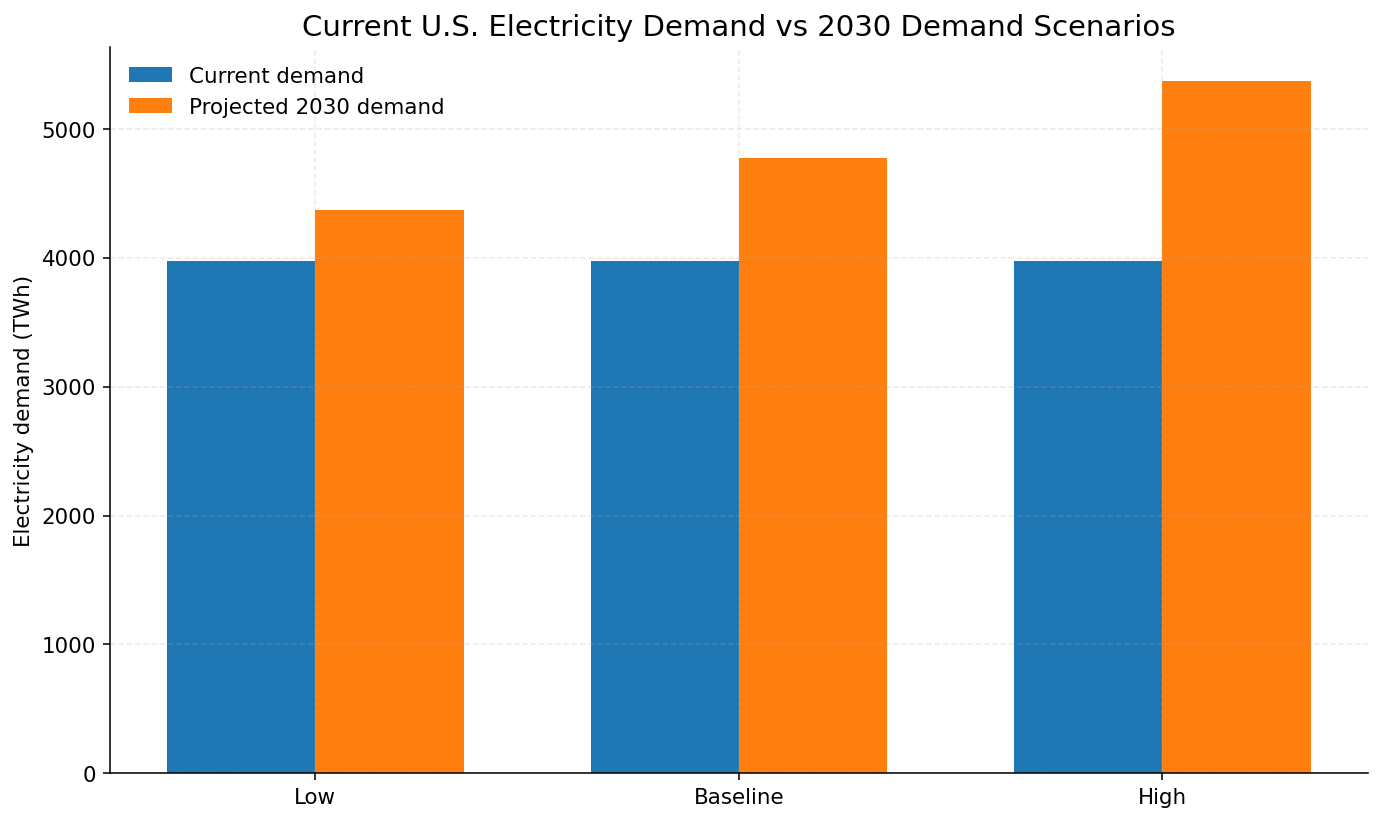

In [7]:
demand_plot_df = power_outlook_2030[
    [
        "scenario",
        "current_demand_mwh",
        "projected_2030_demand_mwh"
    ]
].copy()

demand_plot_df["current_demand_twh"] = (
    demand_plot_df["current_demand_mwh"] / 1_000_000
)

demand_plot_df["projected_2030_demand_twh"] = (
    demand_plot_df["projected_2030_demand_mwh"] / 1_000_000
)

x = np.arange(len(demand_plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    demand_plot_df["current_demand_twh"],
    width,
    label="Current demand"
)

plt.bar(
    x + width / 2,
    demand_plot_df["projected_2030_demand_twh"],
    width,
    label="Projected 2030 demand"
)

plt.xticks(x, demand_plot_df["scenario"])
plt.ylabel("Electricity demand (TWh)")
plt.title("Current U.S. Electricity Demand vs 2030 Demand Scenarios")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig7_1_current_vs_2030_demand.png",
    bbox_inches="tight"
)

plt.show()

## Figure 2: Current Capacity vs 2030 Capacity Scenarios

This figure compares current U.S. net summer capacity with projected 2030 capacity under different planned-capacity realization assumptions.

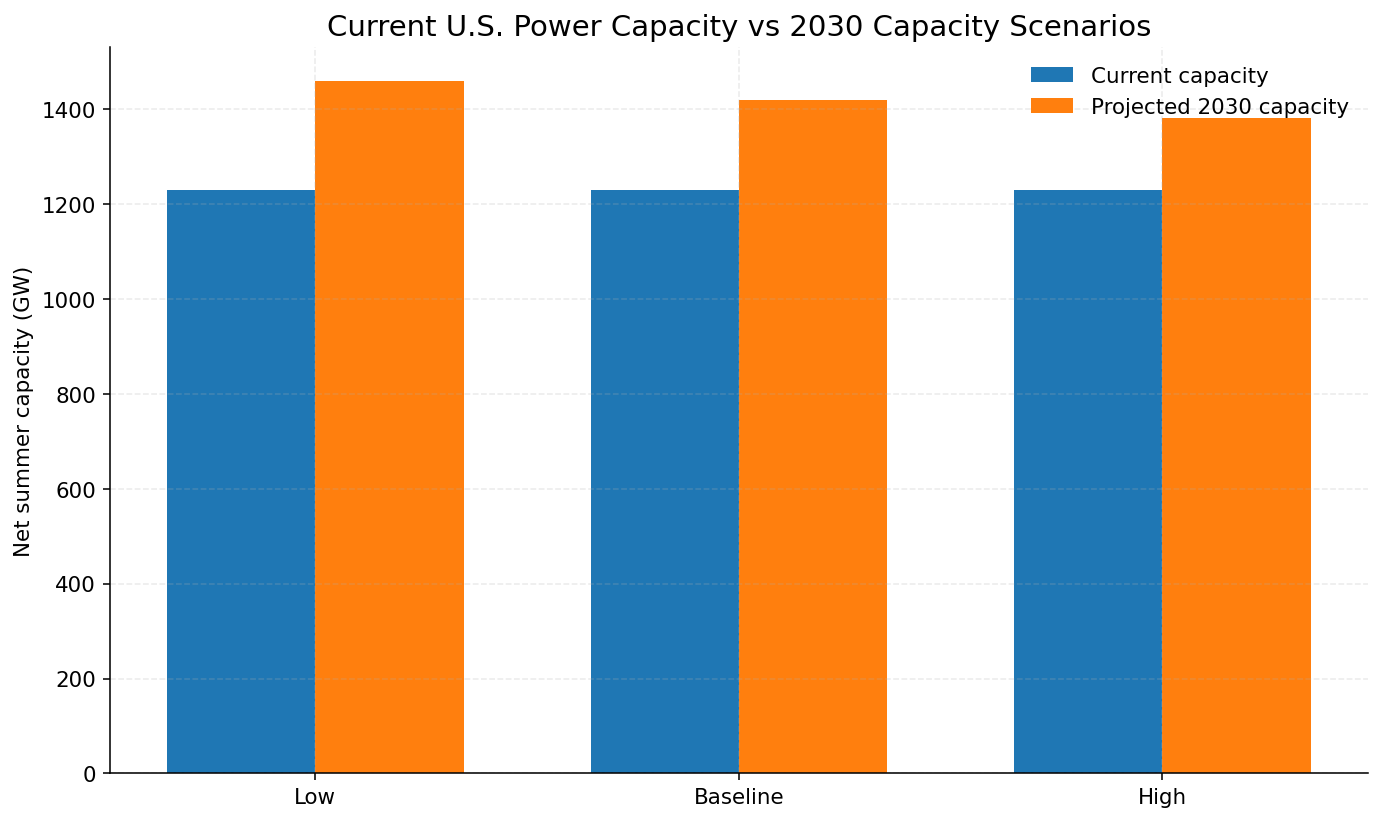

In [8]:
capacity_plot_df = power_outlook_2030[
    [
        "scenario",
        "current_capacity_mw",
        "projected_2030_capacity_mw"
    ]
].copy()

capacity_plot_df["current_capacity_gw"] = (
    capacity_plot_df["current_capacity_mw"] / 1_000
)

capacity_plot_df["projected_2030_capacity_gw"] = (
    capacity_plot_df["projected_2030_capacity_mw"] / 1_000
)

x = np.arange(len(capacity_plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    capacity_plot_df["current_capacity_gw"],
    width,
    label="Current capacity"
)

plt.bar(
    x + width / 2,
    capacity_plot_df["projected_2030_capacity_gw"],
    width,
    label="Projected 2030 capacity"
)

plt.xticks(x, capacity_plot_df["scenario"])
plt.ylabel("Net summer capacity (GW)")
plt.title("Current U.S. Power Capacity vs 2030 Capacity Scenarios")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig7_2_current_vs_2030_capacity.png",
    bbox_inches="tight"
)

plt.show()

## Figure 3: Demand Growth vs Capacity Growth

This figure compares projected electricity demand growth with projected generation capacity growth.

The objective is to determine whether planned capacity additions appear sufficient under different demand-growth scenarios.

If demand growth exceeds capacity growth, grid stress is likely to increase and alternative infrastructure strategies may become more attractive.

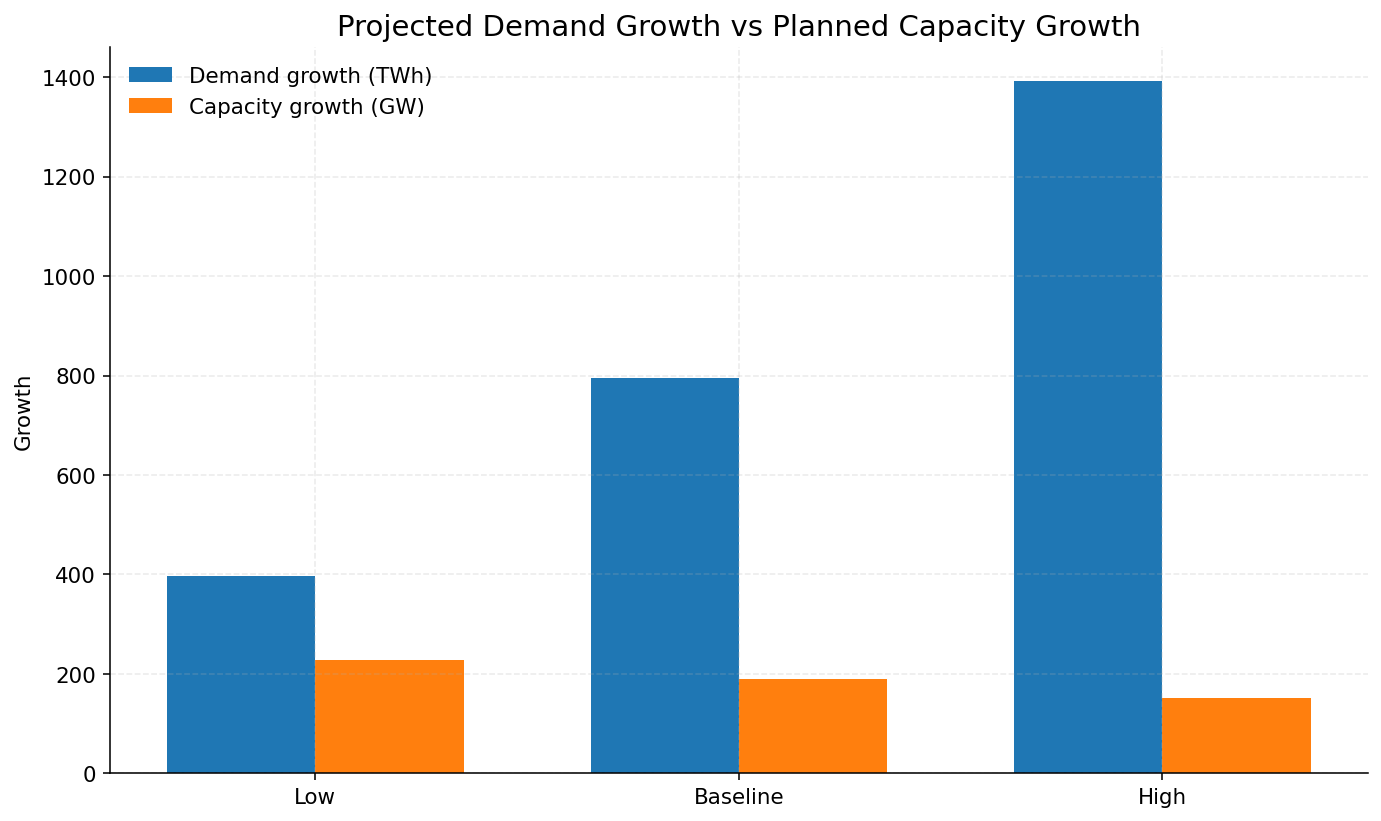

In [9]:
growth_plot_df = power_outlook_2030.copy()

growth_plot_df["demand_growth_twh"] = (
    growth_plot_df["demand_growth_mwh"] / 1_000_000
)

growth_plot_df["capacity_growth_gw"] = (
    growth_plot_df["capacity_growth_mw"] / 1_000
)

x = np.arange(len(growth_plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    growth_plot_df["demand_growth_twh"],
    width,
    label="Demand growth (TWh)"
)

plt.bar(
    x + width / 2,
    growth_plot_df["capacity_growth_gw"],
    width,
    label="Capacity growth (GW)"
)

plt.xticks(x, growth_plot_df["scenario"])

plt.title(
    "Projected Demand Growth vs Planned Capacity Growth"
)

plt.ylabel("Growth")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig7_3_demand_vs_capacity_growth.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
power_outlook_2030[
    [
        "scenario",
        "demand_growth_percent",
        "capacity_realization_percent",
        "demand_growth_mwh",
        "capacity_growth_mw"
    ]
]

,scenario,demand_growth_percent,capacity_realization_percent,demand_growth_mwh,capacity_growth_mw
0,Low,10,90,3.975382e+08,228600.0
1,Baseline,20,75,7.950764e+08,190500.0
2,High,35,60,1.391384e+09,152400.0
